<a href="https://colab.research.google.com/github/randabsk1-maker/mon-projet-colab/blob/main/TP_Breast_Cancer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

travail de:
Bensaker Randa

In [ ]:
!pip install xlrd openpyxl -q

 Prépare l’environnement pour pouvoir importer et manipuler des fichiers

In [ ]:
from google.colab import files
uploaded = files.upload()
# ← Une fenêtre va s'ouvrir → sélectionne TP-EXCEL_.xls

Saving TP-EXCEL.xls to TP-EXCEL (1).xls


on ouvre une fenetre pour importer le fichier excel qui sera stocké dans colab pour analysé

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

on importe des bibliotheque:pandas,matplotlib,seaborn

In [ ]:
FILE = list(uploaded.keys())[0]

df = pd.read_excel(FILE, engine="xlrd", header=0)

 Charger le fichier Excel importé dans un DataFrame
 Les données brutes du fichier sont maintenant accessibles pour traitement.

In [ ]:
df['ER']      = df['breast_carcinoma_estrogen_receptor_status'].map({1:'ER+', 0:'ER-', 'Indeterminate':'Indét.'})
df['Age']     = df['age_at_initial_pathologic_diagnosis']
df['OS']      = df['OS.time']
df['Stage']   = df['pathologic_stage']
df['HER2']    = df['her2_immunohistochemistry_level_result'].astype(str)
df['Meno']    = df['menopause_status'].apply(
    lambda x: 'Post' if 'Post' in str(x) else ('Pré' if 'Pre' in str(x) else 'Autre'))
df['Therapy'] = df['targeted_molecular_therapy']

print("✅ Données chargées :", df.shape)
print(df.head(3))

✅ Données chargées : (1011, 40)
   1  age_at_initial_pathologic_diagnosis  \
0  1                                   79   
1  2                                   69   
2  3                                   68   

               axillary_lymph_node_stage_method_type  \
0  Dissection des ganglions lymphatiques axillair...   
1  Biopsie du ganglion lymphatique sentinelle plu...   
2               Biopsie du ganglion sentinelle seule   

  breast_carcinoma_estrogen_receptor_status  \
0                                         1   
1                                         1   
2                                         0   

  breast_carcinoma_progesterone_receptor_status  days_to_death  \
0                                             1            NaN   
1                                             1            NaN   
2                                             0            NaN   

  days_to_new_tumor_event_after_initial_treatment  DFI  \
0                                             NaN 

But : Nettoyer et créer des colonnes simplifiées (ER, Age, OS, Stage, HER2, Meno, Therapy).

Interprétation : Les variables médicales sont transformées pour être plus lisibles. Exemple : récepteur œstrogène (ER+ ou ER−), statut ménopause (Pré/Post)

In [ ]:
print("─── Stats descriptives ───")
print(df[['Age','OS','DFI','DSS','PAL','BRC','BC','FO']].describe().round(2))

print("\nStatut ER :")
print(df['ER'].value_counts())

print("\nStade pathologique :")
print(df['Stage'].value_counts())

─── Stats descriptives ───
           Age       OS     DFI     DSS     PAL     BRC      BC      FO
count  1011.00  1006.00  864.00  983.00  991.00  991.00  991.00  991.00
mean     62.09  1220.54    0.95    0.91    9.52    7.72   10.24    6.45
std      11.20  1150.90    2.93    2.87    8.43    7.05    1.53    7.09
min      34.00     0.00    0.00    0.00    6.43    1.45    5.31    0.78
25%      53.00   448.50    0.00    0.00    8.29    6.25    9.34    4.74
50%      61.00   850.50    0.00    0.00    8.61    7.13   10.61    5.82
75%      69.50  1615.50    0.00    0.00    8.99    7.90   11.34    6.92
max      90.00  8556.00   10.00   10.00   97.00   91.00   13.48   98.00

Statut ER :
ER
ER+       742
ER-       219
Indét.      3
Name: count, dtype: int64

Stade pathologique :
Stage
Stage IIA        341
Stage IIB        232
Stage IIIA       133
Stage I           93
Stage IA          77
Stage IIIC        57
Stage IIIB        28
Stage IV          19
Stage X           13
Stage II           5
Sta

But : Produire des statistiques descriptives (moyenne, min, max, etc.) et compter les catégories.

Interprétation :

Âge moyen ≈ 62 ans.

Survie globale (OS) très variable (0 à 8556 jours).

Répartition des patientes selon ER et stade pathologique.

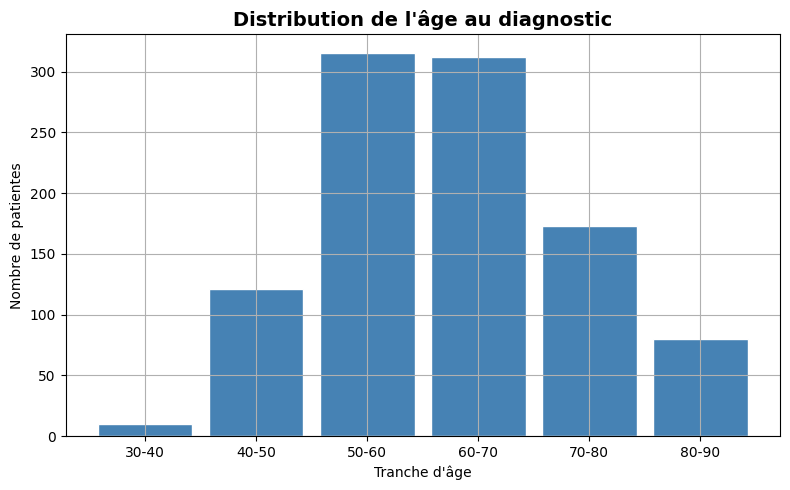

In [ ]:
plt.figure(figsize=(8, 5))
bins = [30, 40, 50, 60, 70, 80, 90]
df['Age'].hist(bins=bins, color='steelblue', edgecolor='white', rwidth=0.85)
plt.title("Distribution de l'âge au diagnostic", fontsize=14, fontweight='bold')
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de patientes")
plt.xticks([35,45,55,65,75,85], ['30-40','40-50','50-60','60-70','70-80','80-90'])
plt.tight_layout()
plt.savefig("fig1_age_distribution.png", dpi=150)
plt.show()

But : Visualiser combien de patientes appartiennent à chaque tranche d’âge (30–40, 40–50, … jusqu’à 80–90 ans).

Résultat :

La majorité des patientes se situe autour de 50–70 ans.

L’âge moyen est d’environ 62 ans (confirmé par les stats descriptives).

On observe moins de cas extrêmes (très jeunes <40 ans ou très âgées >80 ans).

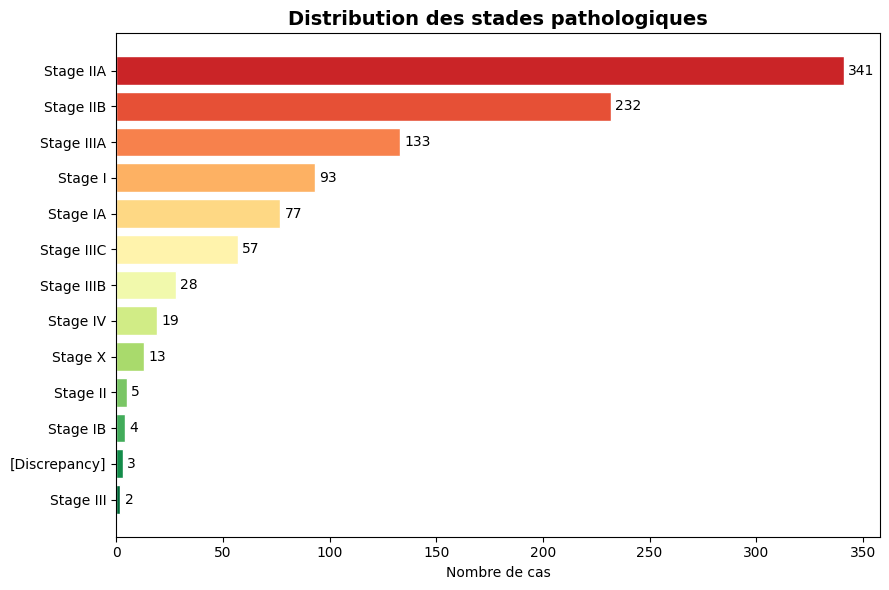

In [ ]:
stage_counts = df['Stage'].value_counts().sort_values()
colors = plt.cm.RdYlGn_r([i/len(stage_counts) for i in range(len(stage_counts))])

plt.figure(figsize=(9, 6))
bars = plt.barh(stage_counts.index, stage_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, stage_counts.values):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.title("Distribution des stades pathologiques", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de cas")
plt.tight_layout()
plt.savefig("fig2_stages.png", dpi=150)
plt.show()


pour Visualiser combien de patientes se trouvent dans chaque stade pathologique (IA, IIA, IIB, IIIA, IIIB, IV…).

Résultat :

Le stade IIA est le plus fréquent (≈ 341 cas).

Viennent ensuite les stades IIB (≈ 232 cas) et IIIA (≈ 133 cas).

Les stades plus précoces (IA, I) et avancés (IIIB, IV) sont moins représentés.La majorité des patientes sont diagnostiquées dans des stades intermédiaires (IIA/IIB), ce qui reflète souvent un diagnostic ni trop précoce ni trop tardif.

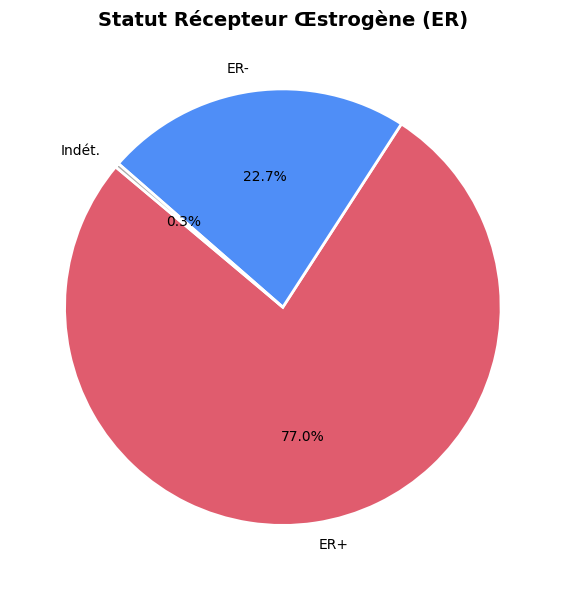

In [ ]:
er_counts = df['ER'].value_counts()

plt.figure(figsize=(6, 6))
colors_er = ['#e05c6e', '#4f8ef7', '#aaaaaa']
plt.pie(er_counts.values, labels=er_counts.index, colors=colors_er,
        autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title("Statut Récepteur Œstrogène (ER)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig3_er_status.png", dpi=150)
plt.show()

But : Visualiser la proportion de patientes selon leur statut ER (ER+, ER−, Indéterminé).

Résultat :

La majorité des patientes sont ER+ (récepteurs œstrogènes positifs).

Une proportion plus faible est ER−.

Une très petite fraction est classée comme indéterminée

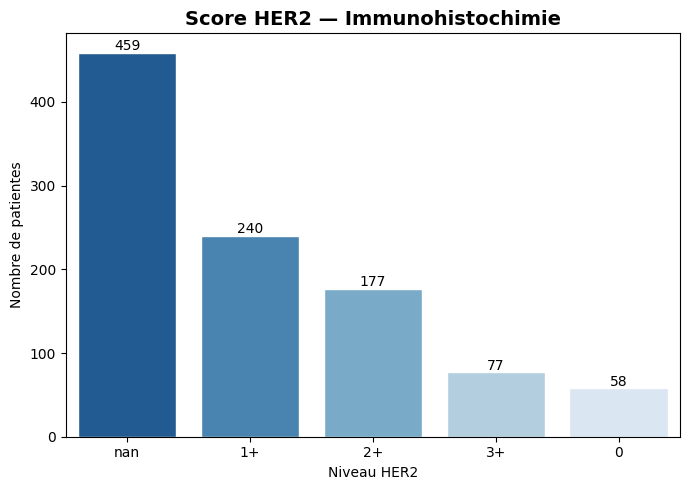

In [ ]:
her2_counts = df['HER2'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=her2_counts.index, y=her2_counts.values,
            palette='Blues_r', edgecolor='white')
plt.title("Score HER2 — Immunohistochimie", fontsize=14, fontweight='bold')
plt.xlabel("Niveau HER2")
plt.ylabel("Nombre de patientes")
for i, v in enumerate(her2_counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("fig4_her2.png", dpi=150)
plt.show()

But : Visualiser la répartition des patientes selon leur score HER2 (1+, 2+, 3+).

Résultat :

Le groupe le plus représenté est HER2 = 1+ (≈ 459 patientes).

Ensuite viennent HER2 = 2+ (≈ 240 patientes).

Enfin, HER2 = 3+ (≈ 177 patientes).

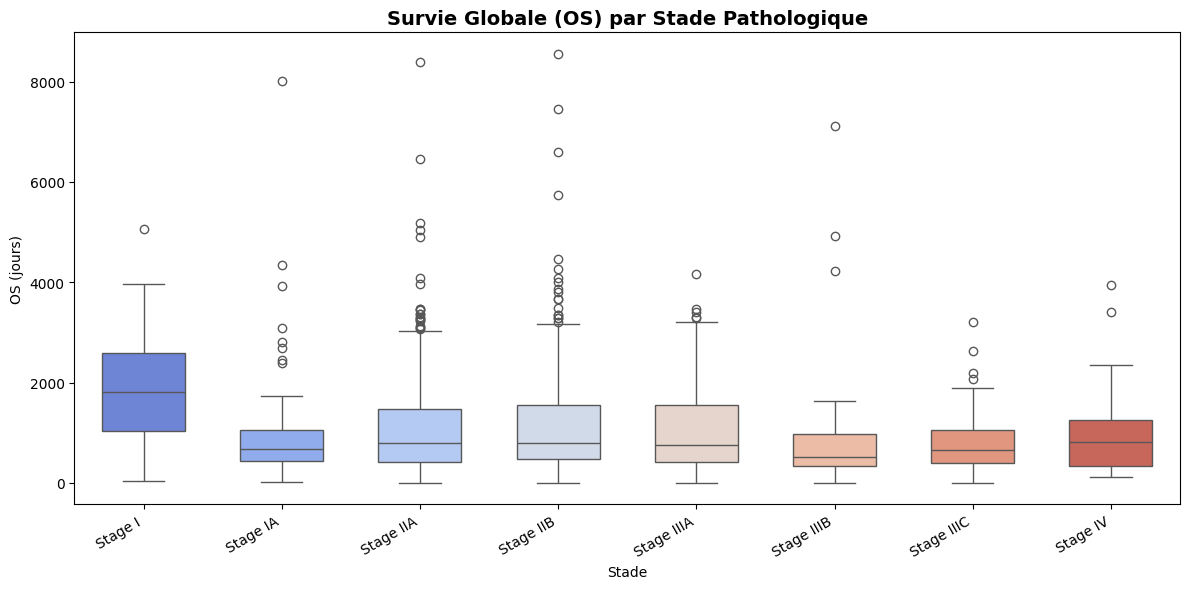

In [ ]:
stage_order = ['Stage I','Stage IA','Stage IIA','Stage IIB',
               'Stage IIIA','Stage IIIB','Stage IIIC','Stage IV']
df_box = df[df['Stage'].isin(stage_order)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_box, x='Stage', y='OS', order=stage_order,
            palette='coolwarm', width=0.6)
plt.title("Survie Globale (OS) par Stade Pathologique", fontsize=14, fontweight='bold')
plt.xlabel("Stade")
plt.ylabel("OS (jours)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("fig5_os_boxplot.png", dpi=150)
plt.show()

But : Comparer la durée de survie des patientes selon le stade du cancer.

Résultat :

Les stades précoces (I, IA) montrent des valeurs de survie plus élevées et plus homogènes.

Les stades intermédiaires (IIA, IIB, IIIA) présentent une survie plus variable, avec des patientes qui vivent longtemps mais aussi des cas de survie courte.
Les stades avancés (IIIB, IIIC, IV) affichent une réduction nette de la survie, avec des médianes plus basses et une dispersion importante.

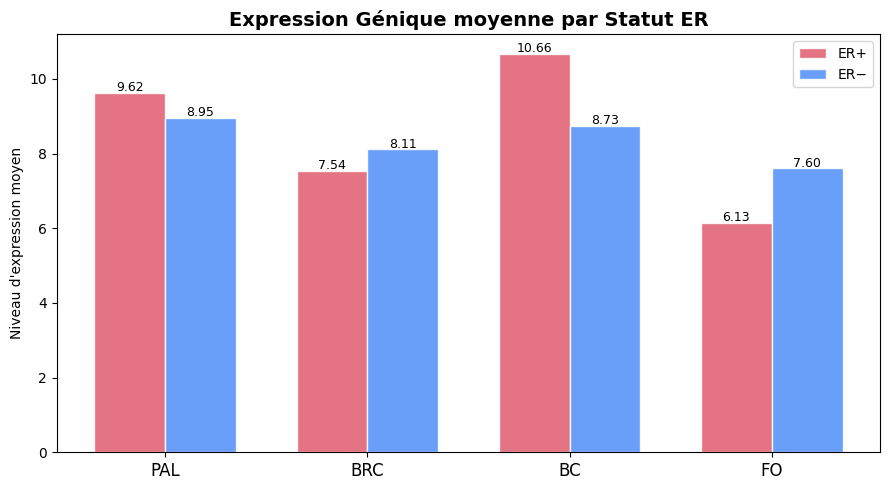

In [ ]:
genes = ['PAL','BRC','BC','FO']
gene_er = df[df['ER'].isin(['ER+','ER-'])].groupby('ER')[genes].mean()

x = range(len(genes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], gene_er.loc['ER+'], width,
               label='ER+', color='#e05c6e', alpha=0.85, edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], gene_er.loc['ER-'], width,
               label='ER−', color='#4f8ef7', alpha=0.85, edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(genes, fontsize=12)
ax.set_title("Expression Génique moyenne par Statut ER", fontsize=14, fontweight='bold')
ax.set_ylabel("Niveau d'expression moyen")
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("fig6_gene_expression.png", dpi=150)
plt.show()

But : Comparer le niveau d’expression de certains gènes (PAL, BRC, BC, FO) entre patientes ER+ et ER−.

Résultat :

Chaque gène est représenté par deux barres côte à côte (ER+ en rouge, ER− en bleu).

On observe des différences d’expression selon le statut ER : certains gènes sont plus exprimés chez les patientes ER+, d’autres chez les ER−.

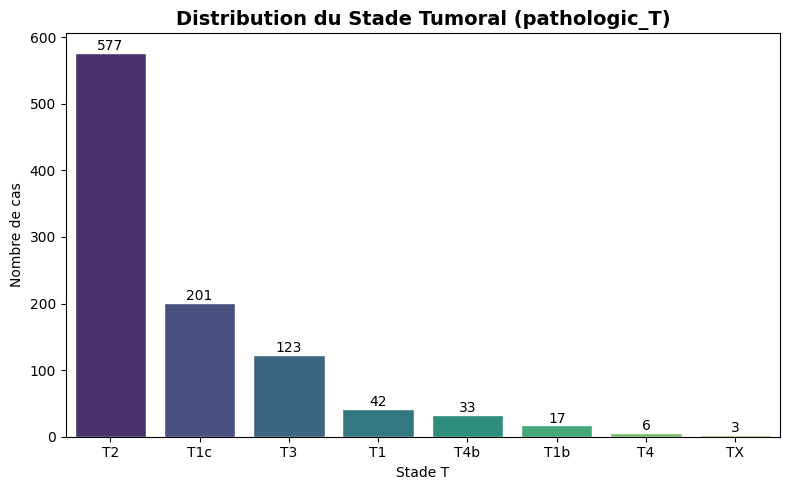

In [ ]:
t_counts = df['pathologic_T'].value_counts().head(8)

plt.figure(figsize=(8, 5))
sns.barplot(x=t_counts.index, y=t_counts.values, palette='viridis', edgecolor='white')
plt.title("Distribution du Stade Tumoral (pathologic_T)", fontsize=14, fontweight='bold')
plt.xlabel("Stade T")
plt.ylabel("Nombre de cas")
for i, v in enumerate(t_counts.values):
    plt.text(i, v + 4, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("fig7_pathologic_T.png", dpi=150)
plt.show()

But : Visualiser combien de patientes se trouvent dans chaque stade tumoral (T1, T2, T3, T4, etc.).

Résultat :

Le stade T1 est le plus fréquent (≈ 577 cas).

Le stade T2 suit avec ≈ 201 cas.

Le stade T3 est moins représenté (≈ 123 cas).

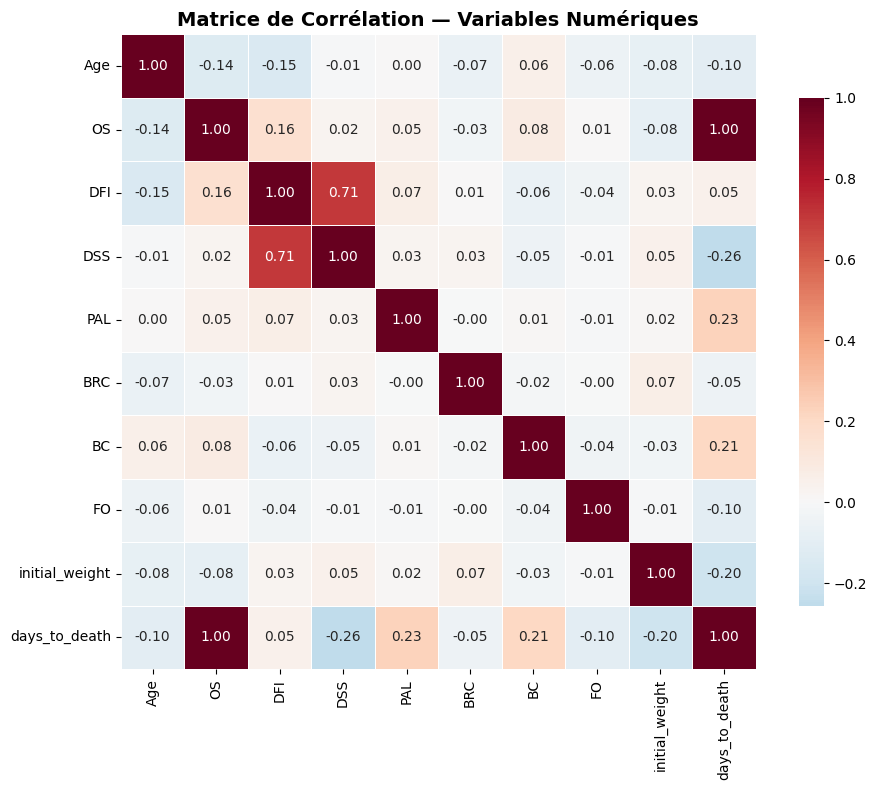

In [ ]:
num_cols = ['Age','OS','DFI','DSS','PAL','BRC','BC','FO',
            'initial_weight','days_to_death']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title("Matrice de Corrélation — Variables Numériques", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig8_correlation_heatmap.png", dpi=150)
plt.show()

But : Identifier les relations statistiques entre différentes variables cliniques et biologiques (âge, survie, gènes, poids initial, etc.).

Résultat :

Les coefficients de corrélation vont de –1 à +1 :

+1 = corrélation parfaite positive (les deux variables évoluent ensemble).

–1 = corrélation parfaite négative (quand l’une augmente, l’autre diminue).
0 = absence de relation linéaire.

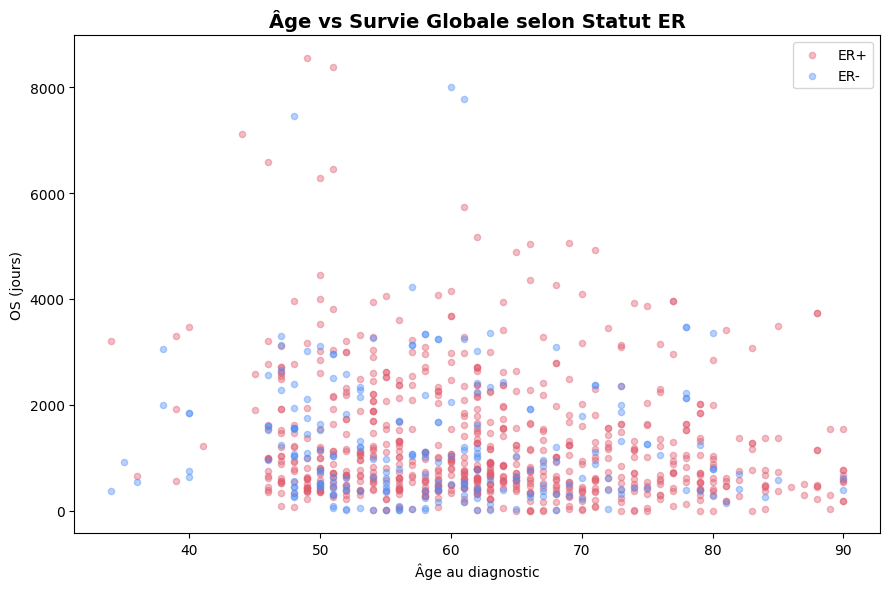

In [ ]:
df_scatter = df[df['ER'].isin(['ER+','ER-'])].dropna(subset=['Age','OS'])

plt.figure(figsize=(9, 6))
for er_val, color in [('ER+', '#e05c6e'), ('ER-', '#4f8ef7')]:
    sub = df_scatter[df_scatter['ER'] == er_val]
    plt.scatter(sub['Age'], sub['OS'], alpha=0.4, s=20,
                color=color, label=er_val)
plt.title("Âge vs Survie Globale selon Statut ER", fontsize=14, fontweight='bold')
plt.xlabel("Âge au diagnostic")
plt.ylabel("OS (jours)")
plt.legend()
plt.tight_layout()
plt.savefig("fig9_age_vs_os.png", dpi=150)
plt.show()

But : Étudier la relation entre l’âge au diagnostic et la survie globale, en distinguant les patientes ER+ et ER−.

Résultat :

Les points rouges représentent les patientes ER+, les bleus les ER−.

On observe une grande dispersion : certaines patientes jeunes ou âgées ont une survie longue, d’autres une survie courte.
Les patientes ER+ semblent globalement avoir une survie plus favorable, mais la variabilité reste importante.

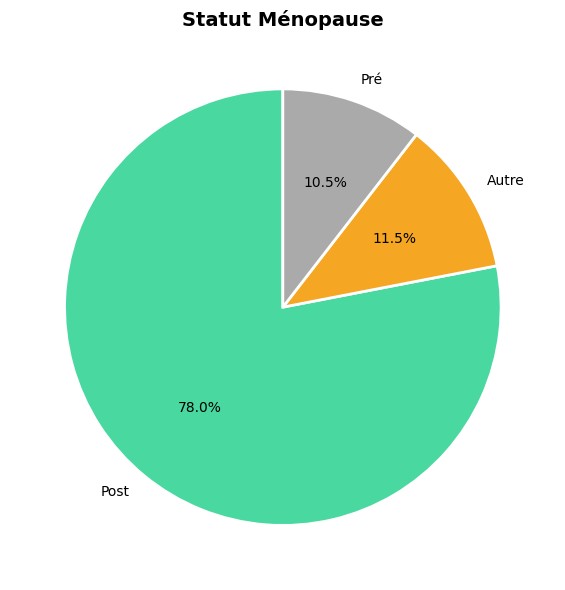

In [ ]:
meno_counts = df['Meno'].value_counts()

plt.figure(figsize=(6, 6))
colors_meno = ['#48d8a0','#f5a623','#aaaaaa']
plt.pie(meno_counts.values, labels=meno_counts.index, colors=colors_meno,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title("Statut Ménopause", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig10_menopause.png", dpi=150)
plt.show()


But : Visualiser la proportion de patientes selon leur statut ménopausique (Pré, Post, ou Autre/Indéterminé).

Résultat :

La majorité des patientes sont en post-ménopause, ce qui est cohérent avec l’âge moyen observé (≈ 62 ans).

Une proportion plus faible est en pré-ménopause.

Une petite fraction est classée comme autre/indéterminé.